# Grupowanie gęstościowe stacji monitoringu sieci za pomocą PROC MODECLUS

## Streszczenie kierownicze

Regionalny zakład dystrybucji energii elektrycznej wykorzystuje PROC MODECLUS
do znajdowania nieparametrycznych, gęstościowych skupisk wśród swoich stacji
monitoringu sieci (stacji transformatorowych i czujników odpływowych)
wyłącznie na podstawie współrzędnych mapy. MODECLUS szacuje powierzchnię
gęstości nad stanowiskami i traktuje skupiska jako obszary wysokiej gęstości
oddzielone lukami niskiej gęstości. Uruchomienie procedury dla 90 symulowanych
stanowisk przy promieniu jądra jednostajnego równym 3 km odtwarza trzy gęste
skupiska usługowe wbudowane w dane jako trzy największe klastry (24, 24 i 21
stanowisk), podczas gdy rozproszone stanowiska wiejskie trafiają do rzadkich
obszarów i tworzą własne jedno- i dwuelementowe mikroskupiska. Ten zbiór
odosobnionych stanowisk jest efektem operacyjnym: listą kandydatów zdalnych
zasobów dla zespołu planowania inwestycji.

## Źródła danych

| Zbiór danych | Wiersze | Opis |
|---------|------|-------------|
| `grid_sites` | 90 | Syntetyczne stanowiska monitoringu sieci elektroenergetycznej wygenerowane w locie za pomocą `call streaminit(70531)` i `rand()`. Trzy gęste skupiska usługowe (Miejski, Podmiejski, Przemysłowy) wylosowane z rozkładów dwuwymiarowych normalnych wokół odrębnych centroidów mapy, plus 22 rozproszone stanowiska Wiejskie wylosowane jednostajnie na terenie całego obszaru. |

| Zmienna | Typ | Opis |
|----------|------|-------------|
| `site_id` | Num | Unikalny identyfikator stanowiska monitoringu (1-90). |
| `region` | Char | Etykieta planistyczna zapisująca sposób wygenerowania każdego stanowiska (Miejski, Podmiejski, Przemysłowy, Wiejski); pominięta w grupowaniu. |
| `x_km`, `y_km` | Num | Lokalizacja stanowiska w kilometrach na siatce planistycznej zakładu; zmienne grupujące. |
| `peak_load_mw` | Num | Zaobserwowane roczne obciążenie szczytowe (MW) na stanowisku; przenoszone do dalszej interpretacji. |

# Grupowanie gęstościowe stacji monitoringu sieci

Regionalny zakład dystrybucji energii elektrycznej eksploatuje sieć
**stanowisk monitoringu** -- stacji transformatorowych i czujników
odpływowych -- rozmieszczonych na całym obszarze świadczenia usług. Planiści
chcą pogrupować te stanowiska w naturalne **skupiska usługowe** wyłącznie na
podstawie geografii, bez wcześniejszego określania liczby grup, oraz
zidentyfikować **odosobnione zasoby wiejskie**, które nie należą do żadnego
gęstego skupiska.

`PROC MODECLUS` doskonale się do tego nadaje: wykonuje grupowanie
*nieparametryczne, gęstościowe*. Szacuje funkcję gęstości nad stanowiskami, a
następnie traktuje skupiska jako obszary wysokiej gęstości stanowisk
oddzielone lukami niskiej gęstości. Rzadkie wartości odstające trafiają do
własnych, maleńkich skupisk zamiast zostać wchłonięte przez skupisko --
dokładnie takie zachowanie, jakiego potrzebujemy do oznaczania odległych
stanowisk.

Ten notatnik:
1. Generuje realistyczną syntetyczną sieć 90 stanowisk.
2. Szacuje gęstość stanowisk za pomocą **jądra jednostajnego** i skanuje
   promień wygładzania `R=`, aby potwierdzić stabilność odtworzonych skupisk.
3. Ustala roboczy promień, zapisuje zbiór `OUT=` z gęstością i etykietą
   skupiska każdego stanowiska, a następnie mapuje wynik.

## Krok 1 -- wygenerowanie syntetycznej sieci stanowisk monitoringu

Symulujemy 90 stanowisk. Trzy gęste **skupiska usługowe** są losowane z
rozkładów dwuwymiarowych normalnych wokół odrębnych centroidów mapy (Miejski w
pobliżu (12, 30), Podmiejski w pobliżu (30, 15), Przemysłowy w pobliżu (20,
42)), dając zwarte bloki o wysokiej gęstości liczące 24, 24 i 20 stanowisk.
Czwarty zbiór 22 stanowisk **Wiejskich** jest losowany jednostajnie na terenie
całego obszaru, dając rzadkie, rozproszone stanowiska, które zakład
traktowałby jako odosobnione.

Etykieta `region` zapisuje sposób wygenerowania każdego stanowiska; celowo
**pomijamy ją** w grupowaniu, aby MODECLUS odkrył strukturę wyłącznie na
podstawie współrzędnych. `peak_load_mw` jest przenoszone do dalszej
interpretacji.

In [1]:
DANE grid_sites;
   CALL streaminit(70531);
   DŁUGOŚĆ region $ 20;

   /* Gęste miejskie skupisko usługowe */
   POWTÓRZ site_id = 1 TO 24;
      region = 'Miejski';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      WYJŚCIE;
   KONIEC;

   /* Skupisko podmiejskie */
   POWTÓRZ site_id = 25 TO 48;
      region = 'Podmiejski';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      WYJŚCIE;
   KONIEC;

   /* Skupisko przemysłowe (wyższe obciążenie szczytowe) */
   POWTÓRZ site_id = 49 TO 68;
      region = 'Przemysłowy';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      WYJŚCIE;
   KONIEC;

   /* Rozproszone stanowiska wiejskie (rzadkie, niskie obciążenie) */
   POWTÓRZ site_id = 69 TO 90;
      region = 'Wiejski';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      WYJŚCIE;
   KONIEC;
WYKONAJ;

TYTUŁ 'Syntetyczne stacje monitoringu sieci';
PROCEDURA MEANS DANE=grid_sites n mean std MIN MAX maxdec=2;
   ETYKIETA region='Region' x_km='Współrzędna X (km)' y_km='Współrzędna Y (km)' peak_load_mw='Szczytowe obciążenie (MW)';
   KLASA region;
   ZMIENNA x_km y_km peak_load_mw;
WYKONAJ;


                                          Syntetyczne stacje monitoringu sieci                                          

                                                  The MEANS Procedure

                                     Analysis Variable : x_km Współrzędna X (km)

        Region                N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------
        Miejski                  24          12.07           1.34           8.65          14.42
        Podmiejski               24          29.96           1.73          26.51          33.60
        Przemysłowy              20          20.36           0.96          18.52          21.53
        Wiejski                  22          29.79          10.62          11.06          47.45
        ---------------------------------------------------------------------------------------

                                     Analysis Variab


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Syntetyczne stacje monitoringu sieci.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Średnie potwierdzają trzy zwarte skupiska i jedną rozproszoną grupę. Trzy
gęste regiony mają małe odchylenia standardowe współrzędnych (mniej więcej
1-1,7 km na każdej osi) wokół dobrze rozdzielonych centroidów, podczas gdy
grupa Wiejska rozciąga się na całej siatce (odchylenia standardowe powyżej 10
km na obu osiach). Obciążenie szczytowe również rozdziela skupiska --
stanowiska Przemysłowe mają średnio około 6 MW, Miejskie około 4,6 MW,
Podmiejskie około 2,7 MW, a Wiejskie około 1,5 MW -- co stanowi przydatny
kontekst, gdy mamy już geograficzne klastry.

## Krok 2 -- grupowanie gęstościowe jądrem jednostajnym i skanowanie promienia

Estymacja gęstości jądrem jednostajnym wykorzystuje **promień `R=`**: każde
stanowisko w odległości `R` kilometrów wnosi wkład do lokalnej gęstości
stanowiska. Małe `R` daje "pofalowaną" gęstość, która fragmentuje obszar; duże
`R` nadmiernie wygładza i scala skupiska. Ekspert SAS nigdy nie ufa
pojedynczej wartości -- skanuje zakres promieni i szuka liczby klastrów, która
jest **stabilna**, gdzie gęste skupiska utrzymują się, a dryfuje jedynie
liczba rozproszonych singletonów.

Tutaj `M=1` wybiera metodę grupowania 1 (standardową metodę nieparametryczną),
a my żądamy promieni `R=2.5 to 4 by 0.5` w jednym wywołaniu. MODECLUS
uruchamia analizę raz dla każdego promienia i raportuje liczbę klastrów dla
każdego z nich. `SHORT` pomija szczegółowe statystyki dla poszczególnych
klastrów.

In [2]:
TYTUŁ 'Grupowanie gęstościowe stacji sieci (jądro jednostajne)';
title2 'Skanowanie promienia R = 2.5 do 4.0 km';

PROCEDURA MODECLUS DANE=grid_sites m=1 r=2.5 TO 4 WEDŁUG 0.5 short;
   ETYKIETA x_km='Współrzędna X (km)' y_km='Współrzędna Y (km)' site_id='Identyfikator stanowiska';
   ZMIENNA x_km y_km;
   ID site_id;
WYKONAJ;


                                Grupowanie gęstościowe stacji sieci (jądro jednostajne)                                 
                                         Skanowanie promienia R = 2.5 do 4.0 km                                         


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: Współrzędna X (km) Współrzędna Y (km)

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to Grupowanie gęstościowe stacji sieci (jądro jednostajne).
NOTE: Option TITLE2 changed to Skanowanie promienia R = 2.5 do 4.0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Liczba klastrów zmienia się tylko nieznacznie w całym skanowaniu -- 23
klastry przy `R=2.5`, 22 przy `R=3.0`, 19 przy `R=3.5` i 18 przy `R=4.0`.
Wysokie surowe liczby wynikają z rozproszonych stanowisk wiejskich: każde
odosobnione stanowisko znajduje się we własnym rzadkim sąsiedztwie i tworzy
jednoelementowy klaster, więc większość 18-23 "klastrów" to pojedyncze
elementy. To, co pozostaje stałe pod spodem, to struktura, która ma znaczenie
-- trzy gęste skupiska pozostają trzema dużymi, dobrze rozdzielonymi
klastrami przy każdym promieniu. W miarę poszerzania `R` kilka rozproszonych
pojedynczych elementów łączy się z sąsiadem lub pobliskim skupiskiem, dlatego
łączna liczba powoli maleje, zamiast gwałtownie się wahać. Ta stabilność jest
sygnałem, że rozwiązanie z trzema skupiskami jest rzeczywiste, a nie
artefaktem jednej szerokości pasma.

## Krok 3 -- ostateczne rozwiązanie klastrowania do mapowania

Widząc, że trzy skupiska są stabilne w całym skanowaniu, ustalamy pojedynczy
roboczy promień (`R=3` km) i żądamy opcji **ALL** dla pełnego wyświetlenia
poszczególnych klastrów, a także **OUT=**, aby zapisać oryginalne
współrzędne razem z oszacowaniem `DENSITY` i przypisaniem `CLUSTER`, tak
abyśmy mogli zmapować wynik. Klastry są numerowane według malejącej gęstości
modalnej, więc najgęstsze skupiska to klastry 1, 2 i 3, a rzadkie stanowiska
otrzymują wyższe numery.

In [3]:
TYTUŁ 'Ostateczne rozwiązanie klastrowania gęstościowego';
title2 'Jądro jednostajne, R = 3 km';

PROCEDURA MODECLUS DANE=grid_sites m=1 r=3 out=join_out ALL;
   ETYKIETA x_km='Współrzędna X (km)' y_km='Współrzędna Y (km)' site_id='Identyfikator stanowiska';
   ZMIENNA x_km y_km;
   ID site_id;
WYKONAJ;


                                   Ostateczne rozwiązanie klastrowania gęstościowego                                    
                                              Jądro jednostajne, R = 3 km                                               


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: Współrzędna X (km) Współrzędna Y (km)

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1     


NOTE: Option TITLE changed to Ostateczne rozwiązanie klastrowania gęstościowego.
NOTE: Option TITLE2 changed to Jądro jednostajne, R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Podsumowanie klastrów jasno pokazuje strukturę. Rozwiązanie `R=3` zwraca
**22 klastry**, ale są one wyraźnie ustopniowane według gęstości:

- **Klaster 1** -- 24 stanowiska, gęstość modalna około 0,0090 (skupisko
  Miejski).
- **Klaster 2** -- 24 stanowiska, gęstość modalna około 0,0079 (skupisko
  Podmiejski).
- **Klaster 3** -- 21 stanowisk, gęstość modalna około 0,0079 (skupisko
  Przemysłowy; przechwytuje jedno stanowisko wiejskie, które znalazło się na
  jego krawędzi).
- **Klastry 4-22** -- grupa trzyelementowa i osiemnaście jednoelementowych
  klastrów, wszystkie przy gęstości modalnej około 0,0004, mniej więcej
  dwadzieścia razy rzadsze niż skupiska.

Trzy gęste skupiska obejmują 69 z 90 stanowisk; pozostałych 21 stanowisk to
rozproszone zasoby wiejskie, z których każde znajduje się samotnie lub
prawie samotnie w rzadkim sąsiedztwie. To gęstość, a nie z góry ustalona
liczba klastrów, wyznacza granicę między skupiskiem usługowym a stanowiskiem
odosobnionym.

## Krok 4 -- zmapowanie klastrów

Oznaczamy każde stanowisko w zależności od tego, czy trafiło do jednego z
trzech gęstych skupisk (`cluster <= 3`), czy do rzadkiego mikroklastra, a
następnie nanosimy każde stanowisko na jego współrzędne mapy, kolorując je
według tego statusu. To widok planisty: gęste skupiska do zarządzania jako
obszary usługowe oraz stanowiska odosobnione do oznaczenia w celu odrębnego
traktowania.

                                    Odzyskane gęste skupiska i stanowiska izolowane                                     
                                  Grupowanie gęstościowe (jądro jednostajne), R = 3 km                                  




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to Odzyskane gęste skupiska i stanowiska izolowane.
NOTE: Option TITLE2 changed to Grupowanie gęstościowe (jądro jednostajne), R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


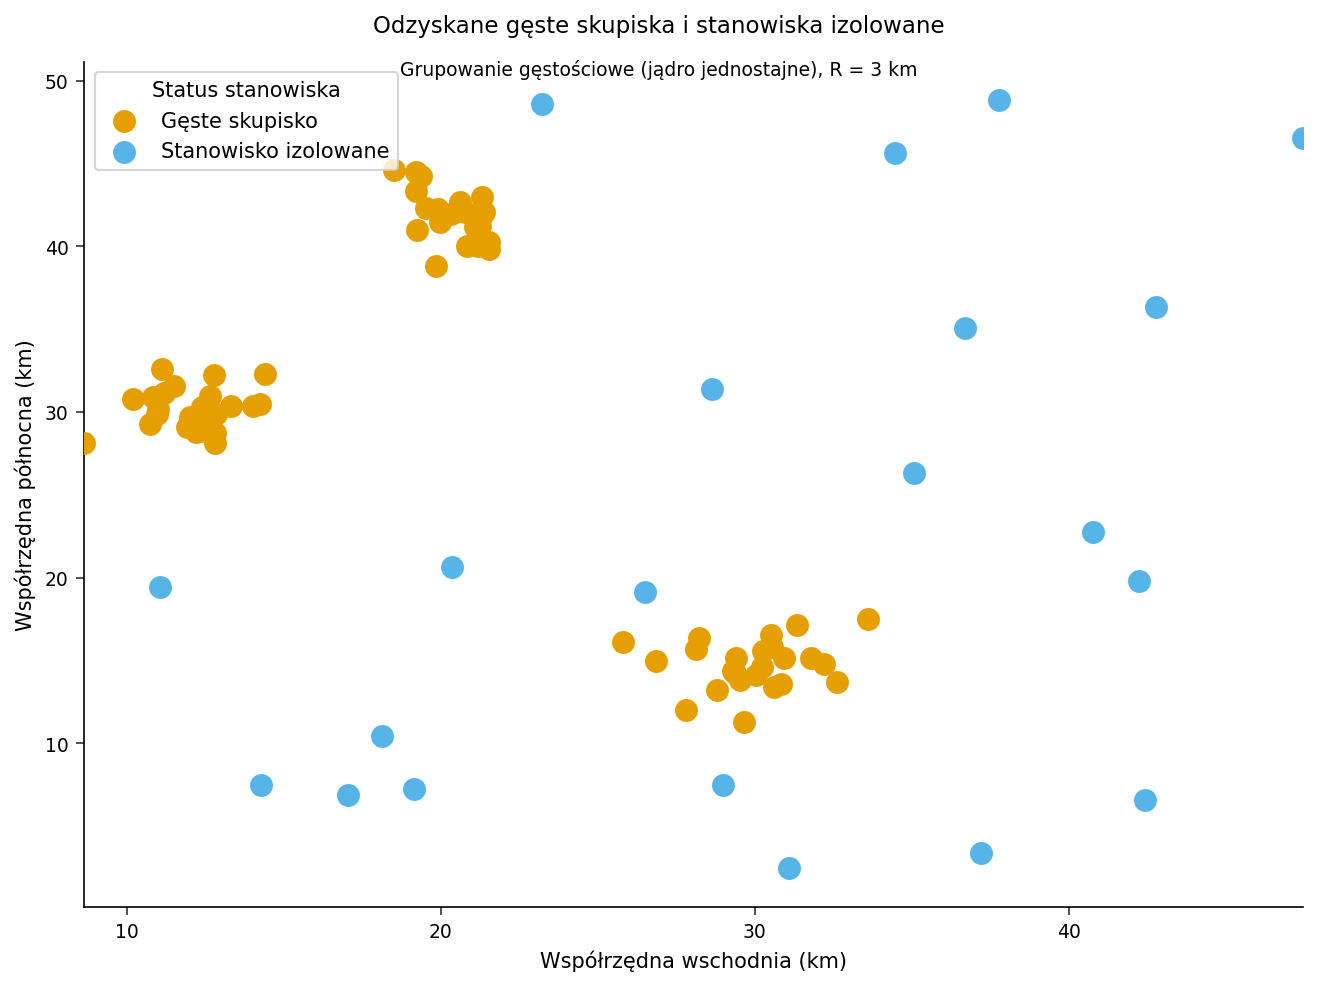

In [4]:
DANE mapped;
   USTAW join_out;
   DŁUGOŚĆ status $ 30;
   JEŚLI CLUSTER <= 3 WTEDY status = 'Gęste skupisko';
   PRZECIWNIE status = 'Stanowisko izolowane';
WYKONAJ;

TYTUŁ 'Odzyskane gęste skupiska i stanowiska izolowane';
title2 'Grupowanie gęstościowe (jądro jednostajne), R = 3 km';
PROCEDURA SGPLOT DANE=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=CLUSTER
                           MARKERATTRS=(size=10);
   XAXIS ETYKIETA='Współrzędna wschodnia (km)';
   YAXIS ETYKIETA='Współrzędna północna (km)';
   keylegend / TYTUŁ='Status stanowiska';
WYKONAJ;

TYTUŁ;


## Interpretacja wyników

**Co znalazł MODECLUS.** Kierując się wyłącznie `(x_km, y_km)`, procedura
odtwarza trzy gęste skupiska usługowe wbudowane w dane -- bloki Miejski,
Podmiejski i Przemysłowy -- jako trzy największe, najgęstsze klastry (24, 24
i 21 stanowisk). Rozproszone stanowiska wiejskie, losowane jednostajnie na
terenie całego obszaru, trafiają do rzadkich obszarów i odłączają się we
własne jedno- i dwuelementowe klastry zamiast zostać wchłonięte przez
skupisko. Na mapie są to punkty oddzielone od trzech zwartych bloków. Ten
zbiór odosobnionych stanowisk jest efektem operacyjnym: listą kandydatów
zdalnych zasobów dla zespołu planowania inwestycji.

**Dlaczego skanowanie wygładzania ma znaczenie.** Żadne pojedyncze `R` nie
jest autorytatywne dla nieparametrycznego grupowania gęstościowego.
Skanowanie `R=2.5 to 4 by 0.5` pozwala nam potwierdzić, że skupiska są
*stabilne* w różnych poziomach wygładzania, a nie są artefaktem jednej
szerokości pasma. W całym skanowaniu liczba klastrów zmienia się jedynie z
23 do 18, a zmiana dotyczy wyłącznie liczby rozproszonych pojedynczych
elementów -- trzy gęste skupiska utrzymują się przez cały czas. Tam, gdzie
struktura pozostała stabilna w ten sposób, mamy rozwiązanie obronne; gdyby
liczba gwałtownie się wahała, struktura byłaby krucha i nie powinna
kierować decyzjami inwestycyjnymi.

**Gęstość stopniuje wynik.** Ponieważ klastry są numerowane według malejącej
gęstości modalnej, podział między skupiskami a stanowiskami odosobnionymi
jest ilościowy, a nie arbitralny: trzy skupiska mają gęstość modalną w
okolicach 0,008-0,009, podczas gdy każde odosobnione stanowisko ma gęstość w
okolicach 0,0004, czyli około dwadzieścia razy rzadszą. Planista może ustalić
próg gęstości i odczytać odosobnione zasoby bezpośrednio z kolumn `CLUSTER` i
`DENSITY` zbioru `join_out`.

**Praktyczne zastosowanie.** Zbiór `join_out` nadaje każdemu stanowisku
gęstość i etykietę klastra, które mogą zasilić dalsze prace -- dobór
liczebności ekip i części zamiennych na skupisko usługowe, planowanie tras
inspekcji lub priorytetyzację wzmacniania sieci w gęstym klastrze
przemysłowym (najwyższe `peak_load_mw`, około 6 MW), przy jednoczesnym
planowaniu rzadszej konserwacji dla odosobnionych stanowisk wiejskich.

*Uwaga o danych syntetycznych:* współrzędne i obciążenia są symulowane ze
stałym ziarnem (`call streaminit(70531)`), dzięki czemu notatnik jest w pełni
odtwarzalny offline; na rzeczywistych danych zakładu podstawilibyśmy
zmierzone współrzędne stanowisk i mierzone obciążenia szczytowe. Dokładne
liczby klastrów zależą od losowania i wybranego promienia.